In [1]:
from scipy.spatial import distance_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
np.random.seed(1) # genera que siempre den igual los resultados
clicks = np.concatenate(
    (np.random.uniform(1,5,10),
     np.random.uniform(7,10,10),
     np.random.normal(3,1,10),
     np.random.normal(8.5,1,10))
).round(2)
compras = np.concatenate(
    (np.random.uniform(1,5,10),
     np.random.normal(3,1,10),
     np.random.uniform(7,10,10),
     np.random.normal(8.5,1,10))
).round(0)

data = pd.DataFrame(
    {
        "Clicks": (clicks*100).astype("int"),
        "Compras": compras.astype("int")
    }
)
data.head()

,Clicks,Compras
0,267,3
1,388,1
2,100,3
3,221,2
4,159,3


<Axes: xlabel='Clicks', ylabel='Compras'>

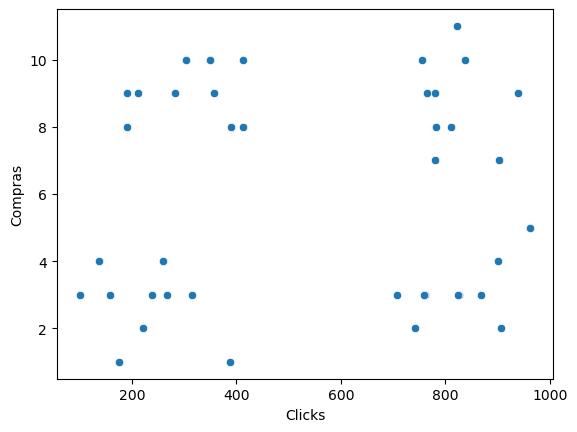

In [12]:
sns.scatterplot(data = data, x = "Clicks", y = "Compras")

In [4]:
data_normalizada = (data - data.min()) / (data.max() - data.min())

In [5]:
data_normalizada.head()

,Clicks,Compras
0,0.193511,0.2
1,0.333720,0.0
2,0.000000,0.2
3,0.140209,0.1
4,0.068366,0.2


<Axes: xlabel='Clicks', ylabel='Compras'>

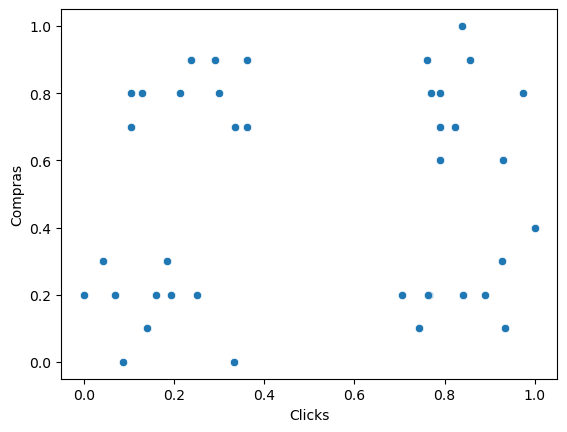

In [9]:
sns.scatterplot(data = data_normalizada, x = "Clicks", y = "Compras")

In [14]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [15]:
Z = linkage(
    data_normalizada,
    method = "centroid",
    metric = "euclidean"
)

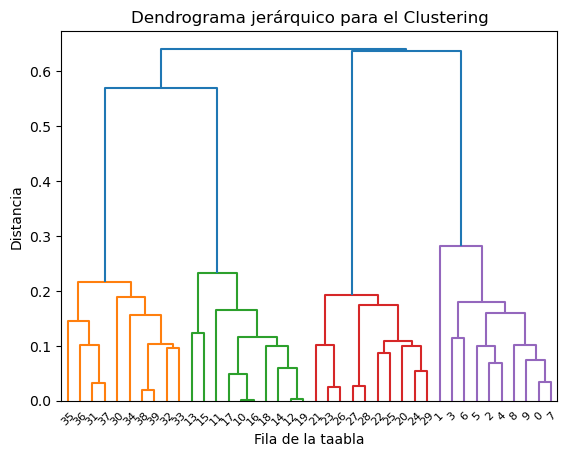

In [17]:
plt.title("Dendrograma jerárquico para el Clustering")
plt.xlabel("Fila de la taabla")
plt.ylabel("Distancia")
dendrogram(Z)
plt.show()

In [18]:
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

In [20]:
distancia_original = pdist(data_normalizada)

In [21]:
cophenet(Z, distancia_original)[0]

np.float64(0.8431017857229921)

In [23]:
distancias = Z[:,2]
ultimas_distancias = distancias[:-11:-1]
ultimas_distancias

array([0.641677  , 0.63752794, 0.57007727, 0.28139374, 0.23289964,
       0.21667443, 0.19296775, 0.18860669, 0.17919183, 0.17440646])

Text(0, 0.5, 'Distancias')

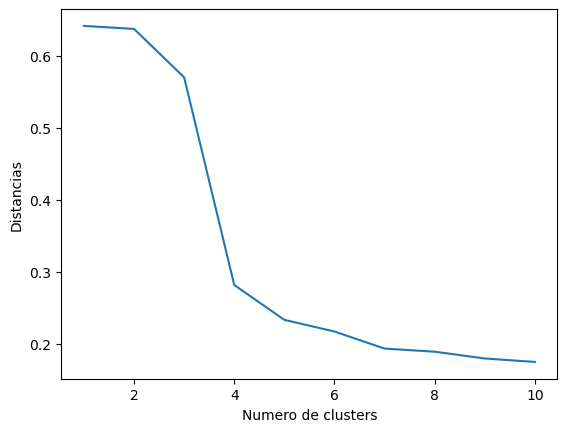

In [25]:
clusters = range(1, len(ultimas_distancias)+1)
sns.lineplot(
    x = clusters,
    y = ultimas_distancias
)
plt.xlabel("Numero de clusters")
plt.ylabel("Distancias")

In [26]:
from scipy.cluster.hierarchy import fcluster

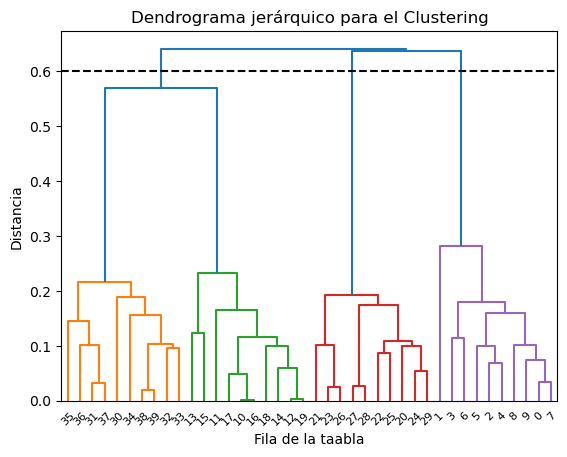

In [27]:
plt.title("Dendrograma jerárquico para el Clustering")
plt.xlabel("Fila de la taabla")
plt.ylabel("Distancia")
dendrogram(Z)
plt.axhline(y = 0.6, color = "black", ls = "--")
plt.show()

In [28]:
clusters = fcluster(Z, 0.6, criterion = "distance")
data["clusters"] = clusters

<Axes: xlabel='Clicks', ylabel='Compras'>

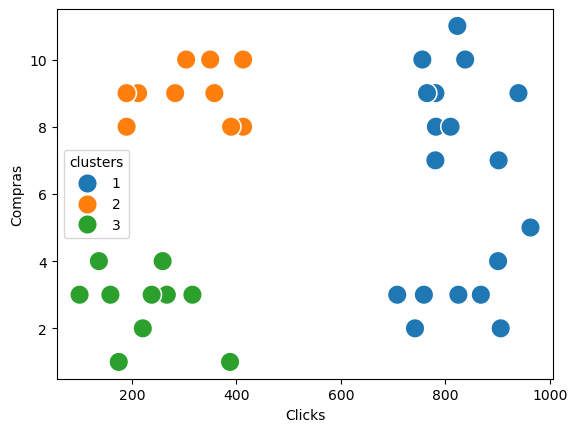

In [32]:
sns.scatterplot(
    data = data, 
    x = "Clicks", 
    y = "Compras", 
    s = 200, 
    hue = "clusters", 
    palette = "tab10"
)

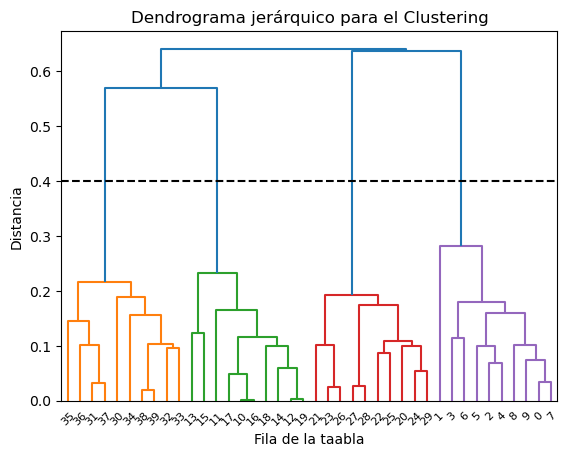

In [33]:
plt.title("Dendrograma jerárquico para el Clustering")
plt.xlabel("Fila de la taabla")
plt.ylabel("Distancia")
dendrogram(Z)
plt.axhline(y = 0.4, color = "black", ls = "--")
plt.show()

In [35]:
clusters = fcluster(Z, 0.4, criterion = "distance")
data["clusters"] = clusters

<Axes: xlabel='Clicks', ylabel='Compras'>

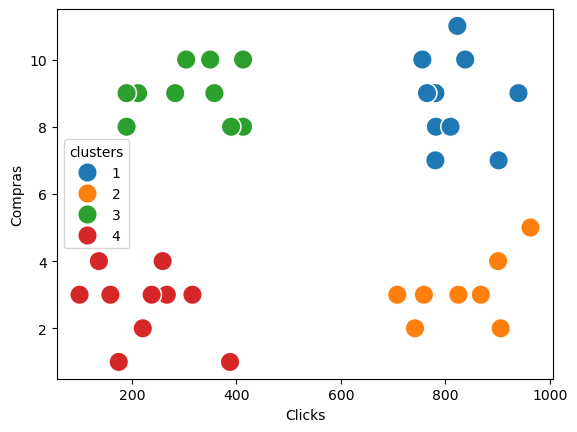

In [36]:
sns.scatterplot(
    data = data, 
    x = "Clicks", 
    y = "Compras", 
    s = 200, 
    hue = "clusters", 
    palette = "tab10"
)

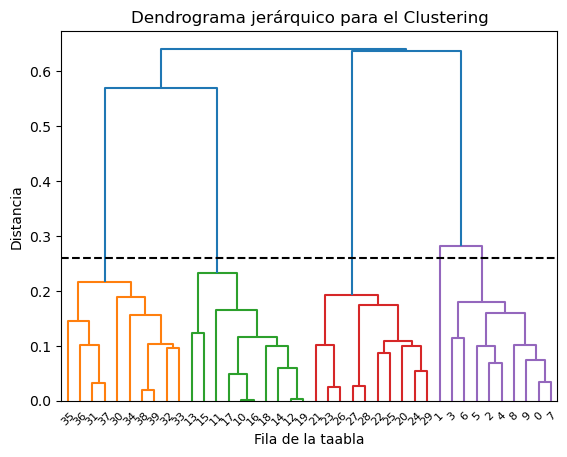

In [37]:
plt.title("Dendrograma jerárquico para el Clustering")
plt.xlabel("Fila de la taabla")
plt.ylabel("Distancia")
dendrogram(Z)
plt.axhline(y = 0.26, color = "black", ls = "--")
plt.show()

In [38]:
clusters = fcluster(Z, 0.26, criterion = "distance")
data["clusters"] = clusters

<Axes: xlabel='Clicks', ylabel='Compras'>

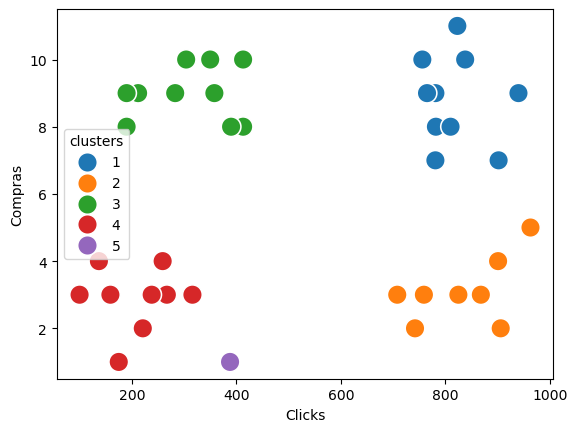

In [39]:
sns.scatterplot(
    data = data, 
    x = "Clicks", 
    y = "Compras", 
    s = 200, 
    hue = "clusters", 
    palette = "tab10"
)

In [43]:
data_normalizada.head()

,Clicks,Compras
0,0.193511,0.2
1,0.333720,0.0
2,0.000000,0.2
3,0.140209,0.1
4,0.068366,0.2


In [40]:
Z = linkage(
    data_normalizada,
    method = "single",
    metric = "euclidean"
)

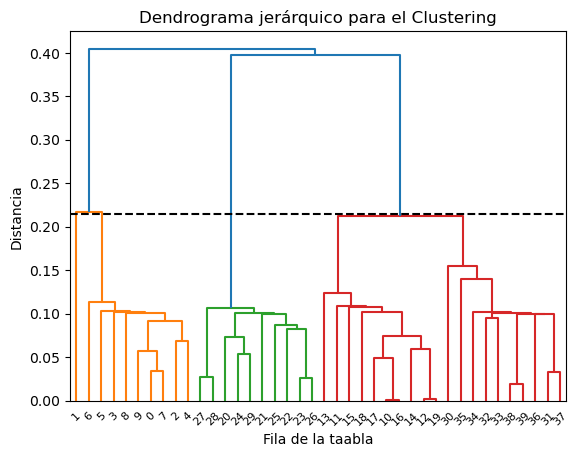

In [46]:
plt.title("Dendrograma jerárquico para el Clustering")
plt.xlabel("Fila de la taabla")
plt.ylabel("Distancia")
dendrogram(Z)
plt.axhline(y = 0.215, color = "black", ls = "--")
plt.show()

In [47]:
clusters = fcluster(Z, 0.215, criterion = "distance")
data["clusters"] = clusters

<Axes: xlabel='Clicks', ylabel='Compras'>

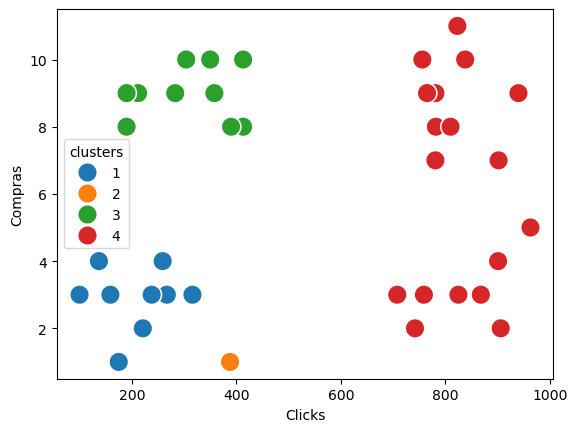

In [48]:
sns.scatterplot(
    data = data, 
    x = "Clicks", 
    y = "Compras", 
    s = 200, 
    hue = "clusters", 
    palette = "tab10"
)